In [ ]:
import pandas as pd
import seaborn as sns

In [2]:
sd_train = pd.read_csv("../data/sd_splits/sd_train.csv", index_col=0)
sd_val = pd.read_csv("../data/sd_splits/sd_val.csv", index_col=0)
sd_test = pd.read_csv("../data/sd_splits/sd_test.csv", index_col=0)

dr_train = pd.read_csv("../data/dr_splits/dr_train.csv", index_col=0)
dr_val = pd.read_csv("../data/dr_splits/dr_val.csv", index_col=0)
dr_test = pd.read_csv("../data/dr_splits/dr_test.csv", index_col=0)

lipo_train = pd.read_csv("../data/lipo_splits/lipo_train.csv", index_col=0)
lipo_val = pd.read_csv("../data/lipo_splits/lipo_val.csv", index_col=0)
lipo_test = pd.read_csv("../data/lipo_splits/lipo_test.csv", index_col=0)

qm7_train = pd.read_csv("../data/qm7_splits/qm7_train.csv", index_col=0)
qm7_val = pd.read_csv("../data/qm7_splits/qm7_val.csv", index_col=0)
qm7_test = pd.read_csv("../data/qm7_splits/qm7_test.csv", index_col=0)

In [3]:
sd_smiles = pd.concat([sd_train["neut-smiles"], sd_val["neut-smiles"], sd_val["neut-smiles"]])
dr_smiles = pd.concat([dr_train["neut-smiles"], dr_val["neut-smiles"], dr_val["neut-smiles"]])
lipo_smiles = pd.concat([lipo_train["smiles"], lipo_val["smiles"], lipo_val["smiles"]])
qm7_smiles = pd.concat([qm7_train["smiles"], qm7_val["smiles"], qm7_val["smiles"]])

In [4]:
(sd_smiles.isin(lipo_smiles)).sum()

np.int64(496)

In [5]:
(sd_smiles.isin(qm7_smiles)).sum()

np.int64(14)

In [6]:
(qm7_smiles.isin(lipo_smiles)).sum()

np.int64(0)

In [7]:
train_overlaps_sd = sd_train[sd_train["neut-smiles"].isin(lipo_smiles) | sd_train["neut-smiles"].isin(qm7_smiles)]
val_overlaps_sd = sd_val[sd_val["neut-smiles"].isin(lipo_smiles) | sd_val["neut-smiles"].isin(qm7_smiles)]
test_overlaps_sd = sd_test[sd_test["neut-smiles"].isin(lipo_smiles) | sd_test["neut-smiles"].isin(qm7_smiles)]

In [8]:
# number of samples dropped
len(train_overlaps_sd), len(val_overlaps_sd), len(test_overlaps_sd)

(410, 50, 45)

In [9]:
sd_train = sd_train[~(sd_train["neut-smiles"].isin(lipo_smiles) | sd_train["neut-smiles"].isin(qm7_smiles))]
sd_val = sd_val[~(sd_val["neut-smiles"].isin(lipo_smiles) | sd_val["neut-smiles"].isin(qm7_smiles))]
sd_test = sd_test[~(sd_test["neut-smiles"].isin(lipo_smiles) | sd_test["neut-smiles"].isin(qm7_smiles))]

In [10]:
sd_train.to_csv('../data/sd_splits/sd_train.csv')
sd_val.to_csv('../data/sd_splits/sd_val.csv')
sd_test.to_csv('../data/sd_splits/sd_test.csv')

In [11]:
train_overlaps_dr = dr_train[dr_train["neut-smiles"].isin(lipo_smiles) | dr_train["neut-smiles"].isin(qm7_smiles)]
val_overlaps_dr = dr_val[dr_val["neut-smiles"].isin(lipo_smiles) | dr_val["neut-smiles"].isin(qm7_smiles)]
test_overlaps_dr = dr_test[dr_test["neut-smiles"].isin(lipo_smiles) | dr_test["neut-smiles"].isin(qm7_smiles)]

In [12]:
# number of samples with DR dropped
len(train_overlaps_dr), len(val_overlaps_dr), len(test_overlaps_dr)

(3, 2, 0)

In [13]:
dr_train = dr_train[~(dr_train["neut-smiles"].isin(lipo_smiles) | dr_train["neut-smiles"].isin(qm7_smiles))]
dr_val = dr_val[~(dr_val["neut-smiles"].isin(lipo_smiles) | dr_val["neut-smiles"].isin(qm7_smiles))]
dr_test = dr_test[~(dr_test["neut-smiles"].isin(lipo_smiles) | dr_test["neut-smiles"].isin(qm7_smiles))]

In [14]:
dr_train.to_csv('../data/dr_splits/dr_train.csv')
dr_val.to_csv('../data/dr_splits/dr_val.csv')
dr_test.to_csv('../data/dr_splits/dr_test.csv')

<Axes: xlabel='SD', ylabel='Count'>

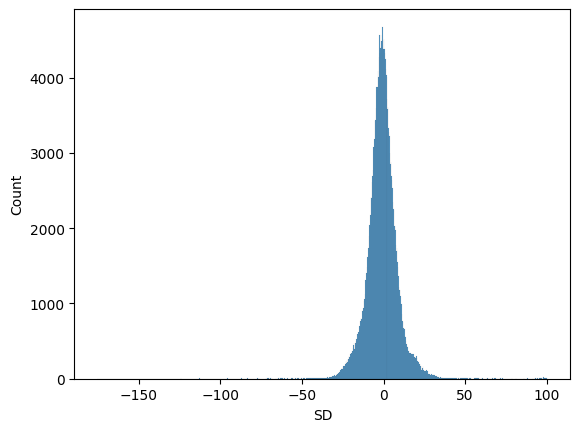

In [ ]:
sns.histplot(sd_train, x="SD")

<Axes: xlabel='SD', ylabel='Count'>

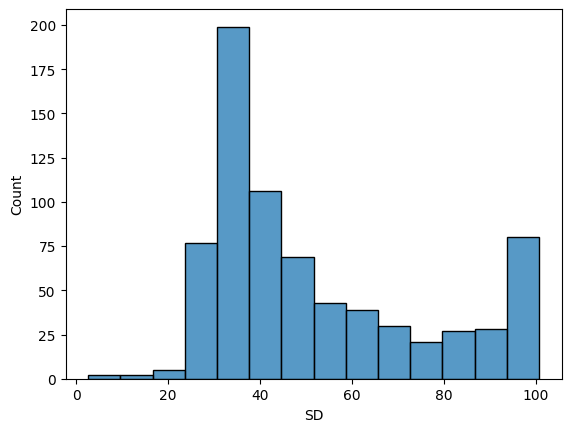

In [23]:
sns.histplot(sd_train.dropna(), x="SD")